# Import Packages

In [1]:
import pickle
import os
from glob import glob
import random
import warnings
import matplotlib.pyplot as plt
from matplotlib import rcParams
from cmcrameri import cm
import seaborn as sns
from pandas import DataFrame, read_parquet
from numpy import arange, array, isnan
import statsmodels.api as sm
from IPython.display import display
from datetime import datetime
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import matplotlib.colors as mcolors
import pydeck as pdk
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import contextily as ctx
import geopandas as gpd
from numpy import abs, nanpercentile
from pathlib import Path

import func_gev as gev
import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style('whitegrid')
%matplotlib inline
cmap = cm.vik

fs = 12

# Settings

In [2]:
path_data = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/exploration/'

dir_results = '../output/gev_analysis/2026-03-04/'
dir_data_pkl = '../output/gev_analysis/2026-03-04/data.parquet'

In [3]:
HINDCAST_START = 1960
HINDCAST_END = 2026

In [4]:
axes_color: str = '#333333'
markers_color: str = "#99E3DDFF"
colors_reg: list = ['#333333FF', '#7F6C7BFF']  

In [5]:
RETURN_PERIODS = [10, 25, 50, 100, 200]
PLOT_PERIOD_EVOLUTION = ['10-year', '50-year', '100-year']

In [6]:
z_ci = 1.645 # two-side 90% CI interval (5% each side)

In [7]:
# adding a little randomness to enhance trust the model works as robust as possible cross locations..
start_location = 830 #random.choice(arange(0, 9579))
end_location = 850#start_location+10

print(f'analyse a subsample of location {start_location}–{end_location}')

analyse a subsample of location 830–850


# Import Data

### Import Raw Data from Models

In [ ]:
ls_files = [file for file in glob(path_data + '*.nc')]
ls_files

In [ ]:
dic_data_per_model = dbf.import_all_models(ls_files)

### Import regression results for location trend regression

In [8]:
[
    results_annual_stat_all, results_nonstat_all, location_geo_info, location_point_info
    ] = ut.import_info_for_regression(dir_results)

loading ../output/gev_analysis/2026-03-04//stationary_per_year.pkl
loading ../output/gev_analysis/2026-03-04//nonstationary.pkl
loading ../output/gev_analysis/2026-03-04//LatLon.pkl
loading ../output/gev_analysis/2026-03-04//location_info.pkl


# Data Processing...

### BiasCorrection,...

In [ ]:
dic_data_per_model, combined, notes_overview = dbf.prepare_combined_data(ls_files, dic_data_per_model)

In [ ]:
dic_data_per_location = dbf.extract_location_data(combined, HINDCAST_START, HINDCAST_END)

# VISUALS

### Plot Map of Missing Data

In [ ]:
n_obs_per_location = dbf.get_number_of_observations_per_site(dic_data_per_location)
n_obs_per_location

In [ ]:
df_missing_location, df_valid, fig_map = dbf.create_summary_location_w_missing_data(
    dic_data_per_model=dic_data_per_model, combined=combined, n_obs_per_location=n_obs_per_location, 
    dir_export=None
    )

In [ ]:
display(fig_map)

### Regression Plot $μ$ - non-stationary vs annual stationary

In [ ]:
dic_fig_regression = {}
ls_missing = []
for loc_id in results_annual_stat_all.keys():
    if loc_id > 2906:
        if results_nonstat_all[loc_id] is None:
            ls_missing.append(loc_id)
            print(f'Skipping side {loc_id}, no nonstationary results (counting {len(ls_missing)})')
            dic_fig_regression[loc_id] = None
            continue
        
        years_, dic_trend = gev.prepare_for_regression(
            annual_stationary=results_annual_stat_all[loc_id], 
            nonstationary=results_nonstat_all[loc_id],
            years_mean=results_nonstat_all[loc_id]['years_mean'], 
            years_std=results_nonstat_all[loc_id]['years_std'], 
            hindcast_start=HINDCAST_START, hindcast_end=HINDCAST_END,
            z_percentile=1.96, factor_m_to_mm=1000
            ) 

        fig_reg = dbplt.plot_location_regression(
            loc_id, years_, dic_trend, results_annual_stat_all[loc_id], fontsize=12,
            axes_color='#333333', markers_color="#99E3DDFF", colors_reg=['#CAA5C2FF',  '#005C55FF'], 
            )
        
        dic_fig_regression[loc_id] = fig_reg

Skipping side 4229, no nonstationary results (counting 1)
Skipping side 4231, no nonstationary results (counting 2)
Skipping side 4241, no nonstationary results (counting 3)
Skipping side 4283, no nonstationary results (counting 4)
Skipping side 4287, no nonstationary results (counting 5)
Skipping side 4301, no nonstationary results (counting 6)
Skipping side 4319, no nonstationary results (counting 7)
Skipping side 4321, no nonstationary results (counting 8)
Skipping side 4337, no nonstationary results (counting 9)
Skipping side 4481, no nonstationary results (counting 10)
Skipping side 4503, no nonstationary results (counting 11)
Skipping side 5369, no nonstationary results (counting 12)
Skipping side 5407, no nonstationary results (counting 13)
Skipping side 5447, no nonstationary results (counting 14)
Skipping side 5477, no nonstationary results (counting 15)
Skipping side 5493, no nonstationary results (counting 16)
Skipping side 5507, no nonstationary results (counting 17)
Skippi

In [ ]:
for loc_id in dic_fig_regression.keys():
    if dic_fig_regression[loc_id]:
        ut.store_location_regression(
            dic_fig_regression[loc_id],loc_id, 
            location_geo_info[loc_id], location_point_info[loc_id], 
            Path('../output/gev_analysis/2026-03-05/')
            )

NameError: name 'dic_fig_regression' is not defined

### Plot Map of Trends of Non-Stationary and Annual Stationary Approach

two-sided 90% CI -> z = 1.645

#### interactive PyDeck

In [ ]:
def extract_mu_for_all_sites_ns(results):
    dic_mu = dict()
    for loc_id in results.keys():
        try:
            mu0, mu1, _, _ = results[loc_id]['params_hat']
            mu0_std, mu1_std, _, _ = results[loc_id]['params_std']
            dic_mu[loc_id] = (mu0, mu0_std, mu1, mu1_std)
        except:
            dic_mu[loc_id] = (None, None, None, None)
        
    return DataFrame(dic_mu, index=['mu0_mm', 'mu0_std_mm', 'mu1_mm/yr', 'mu1_std_mm/yr']).T*1000


def extract_mu_for_all_sites_astat(results):
    dic_mu = dict()
    for loc_id in results.keys():
        try:
            mu0, mu1 = results[loc_id]['mu_trend']['mu0'], results[loc_id]['mu_trend']['mu1']
            mu0_std, mu1_std = results[loc_id]['mu_trend']['mu0_se'], results[loc_id]['mu_trend']['mu1_se']
            dic_mu[loc_id] = (mu0, mu0_std, mu1, mu1_std)
        except:
            dic_mu[loc_id] = (None, None, None, None)
        
    return DataFrame(dic_mu, index=['mu0_mm', 'mu0_std_mm', 'mu1_mm/yr', 'mu1_std_mm/yr']).T*1000


def get_confidence_intervals_mu1(df_mu, z_ci):
    return DataFrame([
        df_mu['mu1_mm/yr'] - z_ci * df_mu['mu1_std_mm/yr'],
        df_mu['mu1_mm/yr'] + z_ci * df_mu['mu1_std_mm/yr']], index=['mu1_upper', 'mu1_lower']
    ).T
    

def prep_for_plot(result, z_ci, approach):
    if approach == 'non-stationary':
        df_mu = extract_mu_for_all_sites_ns(result)
    elif approach == 'annual-stationary':
        df_mu = extract_mu_for_all_sites_astat(result)
    ci_mu1 = get_confidence_intervals_mu1(df_mu=df_mu, z_ci=z_ci)
    
    rows = []
    for loc_id in df_mu.index:

        lat, lon = location_geo_info[loc_id]

        mu1 = df_mu.loc[loc_id, 'mu1_mm/yr']
        se_mu1 = df_mu.loc[loc_id, 'mu1_std_mm/yr']

        ci_mu1_lower = ci_mu1.loc[loc_id]['mu1_lower']
        ci_mu1_upper = ci_mu1.loc[loc_id]['mu1_upper']
        
        if ci_mu1_lower > ci_mu1_upper:
            a, b = ci_mu1_lower, ci_mu1_upper
            ci_mu1_upper = a
            ci_mu1_lower = b
        significant = not (ci_mu1_lower <= 0 <= ci_mu1_upper)

        rows.append({
            "loc_id": loc_id,
            "lat": lat,
            "lon": lon,
            "mu1": mu1,
            "mu1_std": se_mu1,
            "mu1_ci_lower": ci_mu1_lower,
            "mu1_ci_upper": ci_mu1_upper,
            "significant": significant
        })

    return DataFrame(rows), df_mu


def convert_mu1_to_color(df_plot):    
    df = df_plot.copy()
    
    max_abs = nanpercentile(abs(df["mu1"]), 98)
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    def mu1_to_color(val):
        rgba = cmap(norm(val))
        return [int(255*c) for c in rgba[:3]]

    df["color"] = df["mu1"].apply(mu1_to_color)
    return df


def convert_mu1_to_alpha(df_plot):
    """
    Converting uncertainty into transparency: higher uncertainty → more transparent
    """
    max_se = nanpercentile(abs(df_plot["mu1_std"]), 98)
    def se_to_alpha(se):
        norm_se = min(se / max_se, 1)
        if isnan(norm_se):
            alpha = int(10)
        else:
            alpha = int(255 * (1 - norm_se))      
        return max(alpha, 10)  # prevent fully invisible

    df_plot["alpha"] = df_plot["mu1_std"].apply(se_to_alpha)
    return df_plot


def custom_color_for_mu1(df_plot):

    df_plot = convert_mu1_to_color(df_plot)
    df_plot = convert_mu1_to_alpha(df_plot)

    df_plot["color_rgba"] = df_plot.apply(lambda row: row["color"] + [row["alpha"]],axis=1)
    return df_plot


def plot_mu1_for_sites(
    df_plot, approach, radius=10000, file_name="Map_trend_location_including_ci", saving_map:bool=True
    ):
    df_plot["mu1_str"] = df_plot["mu1"].map("{:.3f}".format)
    df_plot["mu1_std_str"] = df_plot["mu1_std"].map("{:.3f}".format)
    df_plot["mu1_ci_lower_str"] = df_plot["mu1_ci_lower"].map("{:.3f}".format)
    df_plot["mu1_ci_upper_str"] = df_plot["mu1_ci_upper"].map("{:.3f}".format)
    df_plot["lat_str"] = df_plot["lat"].map("{:.3f}".format)
    df_plot["lon_str"] = df_plot["lon"].map("{:.3f}".format)

    layer = pdk.Layer(
        "ScatterplotLayer",
        data=df_plot,
        get_position='[lon, lat]',
        get_fill_color="color_rgba",
        get_radius=radius,  # fixed if using alpha
        pickable=True,
    )

    view_state = pdk.ViewState(
        latitude=df_plot["lat"].mean(),
        longitude=df_plot["lon"].mean(),
        zoom=4,
    )

    deck = pdk.Deck(
        layers=[layer],
        initial_view_state=view_state,
        map_style="https://tiles.openfreemap.org/styles/positron",
        tooltip={
            "html": """
                <b>Location</b><br>
                Lat: {lat_str}<br>
                Lon: {lon_str}<br>
                μ₁: {mu1_str} mm/yr<br>
                std_error: {mu1_std_str} mm/yr<br>
            """,
            "style": {"backgroundColor": "lightgray", "color": axes_color, "padding": "8px"}
        }
        #  ci_lower: {mu1_ci_lower_str} mm/yr<br> ci_upper: {mu1_ci_upper_str} mm/yr<br>
        )

    if saving_map:
        today_ = str(datetime.today().date().isoformat()) 

        output_path = f"../output/gev_analysis/{today_}/figures/"
        os.makedirs(os.path.dirname(output_path), exist_ok=True)

        if approach not in file_name:
            file_name = file_name.split('.')[0] + '_' + '_'.join(approach.split(' ')) + '.html'
        print('map stored as %s', output_path + file_name)
        deck.to_html(output_path + file_name)
    
    return deck


##### Non-Stationary Approach

In [61]:
df_plot_ns, df_mu_ns = prep_for_plot(results_nonstat_all, z_ci, approach='non-stationary')
print(f'non-stationary data: {df_plot_ns.shape} out of {df_mu_ns.shape}')

df_plot_ns = custom_color_for_mu1(df_plot_ns)

non-stationary data: (9589, 8) out of (9589, 4)


In [62]:
map_ns = plot_mu1_for_sites(
    df_plot=df_plot_ns, saving_map=True,
    approach='non-stationary approach', file_name="Map_trend_location_including_ci", 
    )

map stored as %s ../output/gev_analysis/2026-03-05/figures/Map_trend_location_including_ci_non-stationary_approach.html


##### Annual-Stationary Approach

In [66]:
df_plot_astat, df_mu_astat = prep_for_plot(results_annual_stat_all, z_ci, approach='annual-stationary')
print(f'annual stationary data: {df_plot_astat.shape} our of {df_mu_astat.shape}')

df_plot_astat = custom_color_for_mu1(df_plot_astat)

annual stationary data: (9589, 8) our of (9589, 4)


In [70]:
map_astat = plot_mu1_for_sites(
    df_plot=df_plot_astat, saving_map=True, radius=15000, 
    approach='annual-stationary approach', file_name="Map_trend_location_including_ci", 
    )

map stored as %s ../output/gev_analysis/2026-03-05/figures/Map_trend_location_including_ci_annual-stationary_approach.html


#### static Matplotlib

In [71]:
def convert_ci_to_alpha(df_plot):
    max_se = nanpercentile(df_plot["mu1_std"], 98)
    df_plot['alpha'] = (1 - (df_plot['mu1_std']/max_se)).clip(0.2, 1.0)  # min alpha 0.2
    return df_plot


def remove_nan_sites(df_plot):
    ls_nan_loc = []
    for en, a in enumerate(df_plot.alpha):
        if isnan(a):
            ls_nan_loc.append(en)
    print(f'{len(ls_nan_loc)} missing location information')

    return df_plot.dropna()


def initialize_projection(df_clean):
    gdf = gpd.GeoDataFrame(
        df_clean, geometry=gpd.points_from_xy(df_clean['lon'], df_clean['lat']),
        crs="EPSG:4326"  # WGS84
    )

    gdf_web = gdf.to_crs(epsg=3857) 

    max_abs = nanpercentile(abs(gdf['mu1']), 98)
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

    max_se = nanpercentile(gdf['mu1_std'], 98)
    gdf_web['alpha'] = (1 - (gdf_web['mu1_std']/max_se)).clip(0.2, 1.0)
    gdf_web['size'] = 20 + (1 - (gdf_web['mu1_std']/max_se)).clip(0,1) * 180
    
    return gdf_web, norm


def plot_mu1_for_all_sites_v2(
    df_clean, approach, 
    ms=80, edgecolor_marker='white', lw_marker=0.1, figsize=(8,5), display_results:bool=True, save_plot:bool=False, save_path:str|None=None
    ):
    
    gdf_web, norm = initialize_projection(df_clean)
    
    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(
        gdf_web.geometry.x, gdf_web.geometry.y,
        c=gdf_web['mu1'], cmap=cmap, norm=norm, s=ms,
        alpha=gdf_web['alpha'], edgecolor=edgecolor_marker, linewidth=lw_marker
    )

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=6)

    ax.set_axis_off()  
    cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label("Location trend $μ_1$, mm/year")

    plt.title(f"Trend Map $μ_1$ · {approach}", loc='left')

    plt.tight_layout()
    if save_plot:
        if save_path is None:
            raise ValueError('Missing path for output; provide `save_path`...')
        
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True) 
    
        file_name = save_dir / f"Map_trend_location_including_ci_{approach}_approach.png"
        plt.savefig(file_name, dpi=300, bbox_inches='tight')
    
    plt.show() if display_results else plt.close(fig)
    return fig

##### Non-Stationary Approach

In [72]:
df_plot_ns = convert_ci_to_alpha(df_plot_ns)
df_clean_ns = remove_nan_sites(df_plot_ns)

61 missing location information


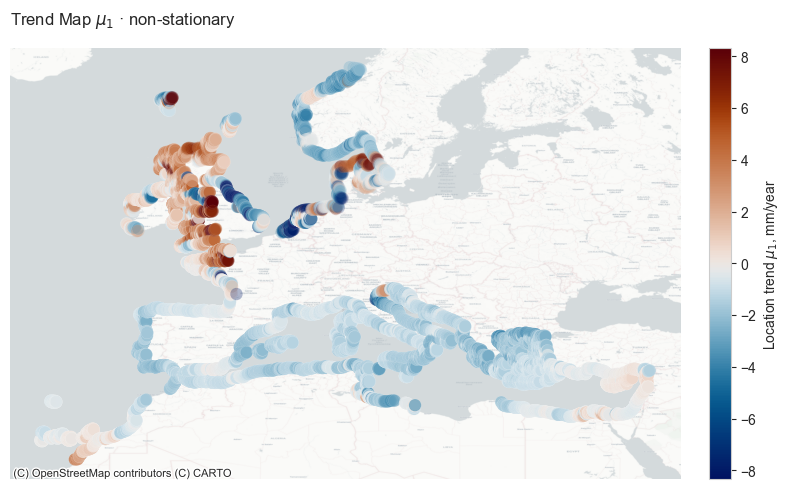

In [73]:
fig_ns = plot_mu1_for_all_sites_v2(
    df_clean_ns, approach='non-stationary', ms=80, 
    display_results=True, save_plot=True, save_path='../output/gev_analysis/2026-03-05/figures/'
    )

##### Annual-Stationary Approach

In [74]:
df_plot_astat = convert_ci_to_alpha(df_plot_astat)
df_clean_astat = remove_nan_sites(df_plot_astat)

0 missing location information


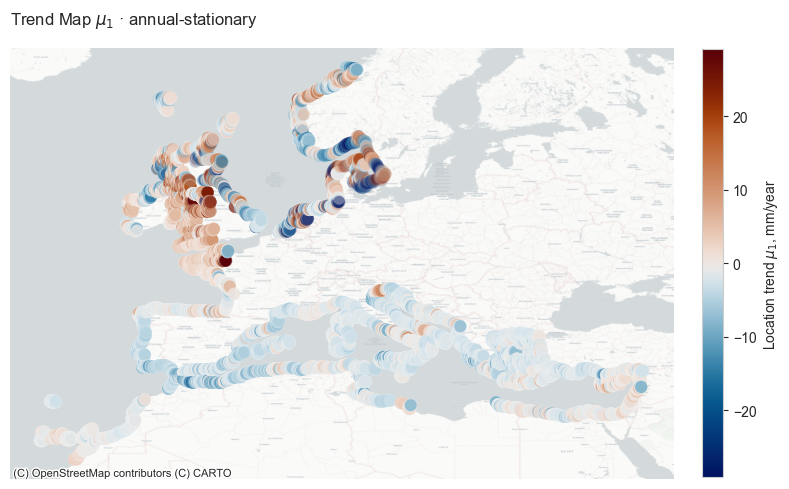

In [75]:
fig_astat = plot_mu1_for_all_sites_v2(
    df_clean_astat, approach='annual-stationary', ms=80, 
    display_results=True, save_plot=True, save_path='../output/gev_analysis/2026-03-05/figures/'
    )